# Temporal Difference (TD) Learning

Temporal Difference learning combines ideas from Monte Carlo (learning from raw experience,
no model needed) and Dynamic Programming (bootstrapping - updating estimates based on other
learned estimates, without waiting for the final outcome).

### TD(0) Update Rule

V(s) <- V(s) + α [ R + γV(s') - V(s) ]

The term `R + γV(s') - V(s)` is called the **TD Error**.

Unlike Monte Carlo, TD(0) updates its value estimate **after every single step**, not at the
end of the episode.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random


In [2]:
# Grid World Setup

rows = 4
cols = 4

goal_state = (3, 3)
actions = ["UP", "DOWN", "LEFT", "RIGHT"]

reward = np.full((rows, cols), -1)
reward[goal_state] = 10

def next_state(state, action):
    row, col = state

    if action == "UP":
        row = max(row - 1, 0)
    elif action == "DOWN":
        row = min(row + 1, rows - 1)
    elif action == "LEFT":
        col = max(col - 1, 0)
    elif action == "RIGHT":
        col = min(col + 1, cols - 1)

    return (row, col)


## TD(0) Prediction (Random Policy)

In [3]:
alpha = 0.1
gamma = 0.9
episodes = 500

V = np.zeros((rows, cols))
td_errors = []

for episode in range(episodes):
    state = (0, 0)
    episode_error = 0
    steps = 0

    for step in range(50):
        action = random.choice(actions)
        next_s = next_state(state, action)
        r = reward[next_s]

        td_error = r + gamma * V[next_s] - V[state]
        V[state] = V[state] + alpha * td_error

        episode_error += abs(td_error)
        steps += 1

        state = next_s

        if state == goal_state:
            break

    td_errors.append(episode_error / steps)

print("Final Value Function:")
print(V)


Final Value Function:
[[-8.41203843 -8.11999401 -7.76799854 -7.30958877]
 [-8.1509645  -7.66496767 -6.9482885  -4.4345104 ]
 [-7.31839714 -6.21249441 -4.06351082  2.76634605]
 [-6.14384376 -2.87826269  2.22266398  0.        ]]


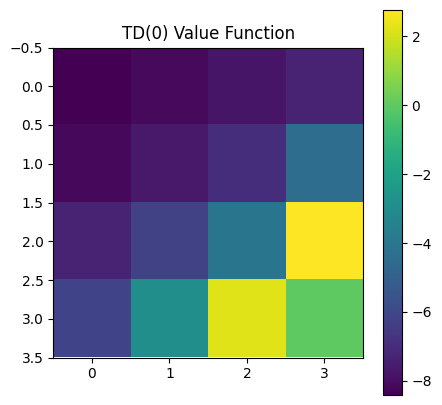

In [4]:
plt.figure(figsize=(5,5))
plt.imshow(V, cmap="viridis")
plt.colorbar()
plt.title("TD(0) Value Function")
plt.show()


## TD Error Over Episodes

As the value function converges, the average TD error per episode should trend downwards.

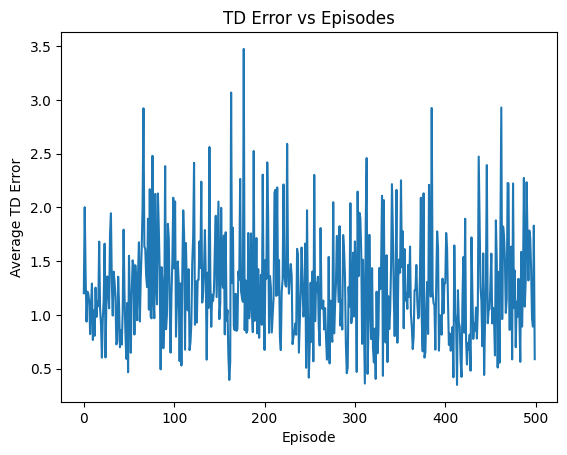

In [5]:
plt.plot(td_errors)
plt.xlabel("Episode")
plt.ylabel("Average TD Error")
plt.title("TD Error vs Episodes")
plt.show()


## Conclusion

TD(0) learns online, one step at a time, by bootstrapping off its own current value estimate
for the next state. This makes it more sample-efficient than Monte Carlo in many settings,
since it doesn't need to wait for an episode to finish before learning something useful.
